# Part I — Fundamentals

## Trefethen & Bau, *Numerical Linear Algebra* (1997) — Lecture 1–5

这是《Numerical Linear Algebra》读书笔记的第 1 册。目标不是摘要原书，而是把每一讲整理成一份**可以独立读懂的数值线性代数讲义**，再把它映射到现代 ML systems。

每一讲尽量保持同一结构：数学对象 → 关键公式 → 几何/算法解释 → numerical stability → ML systems mapping → Python experiment。

本册自洽：下面的 setup cell 提供全部依赖，按顺序 run all 即可。

原书 PDF：https://www.stat.uchicago.edu/~lekheng/courses/309/books/Trefethen-Bau.pdf

---

**本系列共 6 册**（Trefethen & Bau, *Numerical Linear Algebra*, 40 Lectures）

| | |
|---|---|
| Part I | [Fundamentals](01_fundamentals.ipynb) |
| Part II | [QR Factorization and Least Squares](02_qr_least_squares.ipynb) |
| Part III | [Conditioning and Stability](03_conditioning_stability.ipynb) |
| Part IV | [Systems of Equations](04_systems_of_equations.ipynb) |
| Part V | [Eigenvalues](05_eigenvalues.ipynb) |
| Part VI | [Iterative Methods](06_iterative_methods.ipynb) |

索引与阅读顺序见 [00_index.ipynb](00_index.ipynb)。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import scipy.linalg as sla
    import scipy.sparse.linalg as spla
    SCIPY=True
except Exception:
    SCIPY=False
rng=np.random.default_rng(7)
np.set_printoptions(precision=5,suppress=True)

def relerr(a,b):
    return np.linalg.norm(a-b)/max(np.linalg.norm(b),1e-30)

def stable_rank(A):
    s=np.linalg.svd(A,compute_uv=False)
    return np.sum(s*s)/(s[0]*s[0])

def spectral_norm_power(A,steps=30,seed=0):
    r=np.random.default_rng(seed)
    v=r.normal(size=A.shape[1])
    v/=np.linalg.norm(v)
    for _ in range(steps):
        v=A.T@(A@v)
        v/=np.linalg.norm(v)
    return np.linalg.norm(A@v)

def make_cond(n,kappa,seed=0):
    r=np.random.default_rng(seed)
    Q1,_=np.linalg.qr(r.normal(size=(n,n)))
    Q2,_=np.linalg.qr(r.normal(size=(n,n)))
    s=np.geomspace(1,1/kappa,n)
    return Q1@np.diag(s)@Q2.T

print(f'NumPy {np.__version__} | SciPy {SCIPY}')

NumPy 2.4.2 | SciPy True


## Notation / 贯穿全书的符号

我们主要讨论实矩阵；复数情形把转置 $A^T$ 换成共轭转置 $A^*$。

- $A\in\mathbb{R}^{m\times n}$
- 向量 2-norm：

$$
\Vert x\Vert_2=\sqrt{x^Tx}
$$

- induced matrix 2-norm：

$$
\Vert A\Vert_2=\max_{x\neq0}\frac{\Vert Ax\Vert_2}{\Vert x\Vert_2}=\sigma_{\max}(A)
$$

- Frobenius norm：

$$
\Vert A\Vert_F^2=\sum_{ij}a_{ij}^2=\sum_i\sigma_i^2
$$

- condition number：

$$
\kappa_2(A)=\Vert A\Vert_2\Vert A^{-1}\Vert_2
=\frac{\sigma_{\max}}{\sigma_{\min}}
$$

- unit roundoff：记为 $u$。典型 floating-point model：

$$
\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta),\qquad |\delta|\lesssim u.
$$

计算机算一次加减乘除，不会得到精确的 $a\circ b$，而是得到一个带相对误差的结果。逐项：

- $\mathrm{fl}(\cdot)$：floating-point，机器实际算出来的数；
- $a\circ b$：一次精确运算（$\circ$ 是 $+,-,\times,/$）；
- $\delta$：这次运算引入的相对误差；
- $u$：unit roundoff，这种格式「一次正确舍入」的相对误差上限。

左边是机器结果，右边是「真值再乘 $1+\delta$」。约束的是**相对误差**，不是绝对误差：真值若是 $1.0$，FP32 下次运算大约落在 $1\pm 6\times 10^{-8}$，不会无缘无故错到 $1.01$。

常见 $u$：

- FP32：$u\approx 2^{-24}\approx 6\times 10^{-8}$
- FP16：$u\approx 2^{-11}\approx 5\times 10^{-4}$
- BF16：$u\approx 2^{-8}\approx 4\times 10^{-3}$

一次运算只错 $u$。病态问题可能把这个 $u$ 放大成 $\kappa u$ 量级的解误差。所以不要把「格式很粗」「矩阵很病态」「算法多放大了 rounding」三件事混成一句“数值不稳”。

### 区分

不要把下面三个问题混在一起：

1. **operator amplification**：$\Vert A\Vert$ 大不大？
2. **problem conditioning**：$A^{-1}$ 是否敏感？
3. **algorithm stability**：实现是否额外放大 rounding error？

现代 ML numerics 中，大量争论其实是把这三个层次混在了一起。

# Lecture 1 — Matrix-Vector Multiplication

### 1. 数学核心：matrix-vector product 不是“一个算子黑盒”

设

$$
A=[a_1\;a_2\;\cdots\;a_n],\qquad x=(x_1,\ldots,x_n)^T.
$$

那么

$$
Ax=\sum_{j=1}^n x_j a_j.
$$

这叫 **column picture**：输出是列向量的线性组合。另一边，若 $r_i^T$ 是第 $i$ 行，

$$
(Ax)_i=r_i^Tx=\sum_{j=1}^n a_{ij}x_j,
$$

这是 **row / dot-product picture**。

两种视角在 exact arithmetic 完全相同，但数值意义不同。column picture 强调 representation span；row picture 强调 reduction。

### 2. 复杂度与 BLAS 层次

一个 dense matvec 约需要 $2mn$ FLOPs。实际 ML 中通常是 batch GEMM：

$$
Y=XW^T,
$$

计算性能通常由 arithmetic intensity、memory layout、kernel shape、tensor-core tile 决定，而不是仅仅由 FLOP 数决定。

### 3. Numerical stability：dot product 是一连串 rounding

若

$$
s=\sum_{j=1}^n a_jx_j,
$$

实际计算得到

$$
\hat s=\mathrm{fl}\Big(\sum_j \mathrm{fl}(a_jx_j)\Big).
$$

经典误差模型可以写成

$$
|\hat s-s|\lesssim \gamma_n\sum_j|a_jx_j|,
\qquad
\gamma_n\approx nu\quad(nu\ll1).
$$

所以 reduction length、数据尺度和 cancellation 都会影响误差。

### 4. ML mapping

- **training**：activation/gradient GEMM 的 accumulator precision 会改变 reduction error；
- **deployment**：BF16/FP16 input 不代表一定 BF16/FP16 accumulation；
- **compiler**：reassociation、fusion、tiling 都会改变加法顺序，因此“algebraically equivalent”不等于 bitwise equivalent。

下面的实验用 PyTorch 把大量正负小数和一个大数混合，比较 FP64 / FP32 / BF16 / FP16 reduction。

In [10]:
import torch

n = 20000
x = torch.ones(n, dtype=torch.float32)
x[1::2] *= -1
x *= 1e-2
x[0] = 1000

ref = x.to(torch.float64).sum()

def report(name, value):
    err = (value.to(torch.float64) - ref).abs() / ref.abs().clamp_min(1e-30)
    print(f'{name} {value.item()}  relerr {err.item()}')

print(f'FP64 reference {ref.item()}')
report('FP32 reduction', x.sum(dtype=torch.float32))
report('BF16 reduction', x.to(torch.bfloat16).sum(dtype=torch.bfloat16))
report('FP16 reduction', x.to(torch.float16).sum(dtype=torch.float16))

FP64 reference 999.9900000002235
FP32 reduction 999.98974609375  relerr 2.539090126074872e-07
BF16 reduction 1000.0  relerr 1.0000099777478122e-05
FP16 reduction 1000.0  relerr 1.0000099777478122e-05


**ML numerics 自测**

**Q1.** exact arithmetic 里 matvec 用了什么结构？

**A.** $Ax=\sum_j x_j a_j$。column picture 和 row picture 代数上相同，加法结合律成立，求和顺序不影响结果。

**Q2.** finite precision 下最危险的 intermediate 是什么？

**A.** reduction 的 running sum。累加器里已有大数时，比当前 ULP 更小的项再加进去就是 $0$。实验里 $1000\pm 0.01$ 在 BF16/FP16 变成 $1000$。

**Q3.** 这是问题病态，还是实现不稳？

**A.** 这组数的求和本身不病态（真值 $\approx 999.99$）。丢掉的是低精度 accumulate。FP32 accumulate 就能保住那个 $0.01$。

**Q4.** training / deployment 该盯什么？

**A.** accumulator dtype、reduction 长度、数据动态范围，而不是只看 FLOP。GEMM/attention/softmax 都是长 reduction；compiler 重排加法会改变 bitwise 结果。


# Lecture 2 — Orthogonal Vectors and Matrices

### 1. Orthogonality 的本质

若 $q_i^Tq_j=\delta_{ij}$，这些向量构成 orthonormal set。方阵 $Q$ 若满足

$$
Q^TQ=QQ^T=I,
$$

则 $Q^{-1}=Q^T$。

最重要的性质是 2-norm invariance：

$$
\Vert Qx\Vert_2^2=x^TQ^TQx=x^Tx=\Vert x\Vert_2^2.
$$

因此 orthogonal transformation 只改变坐标方向，不引入额外 scale。

### 2. 为什么 numerical linear algebra 特别喜欢 orthogonal transformations

若一个算法用 $Q$ 做 basis change，误差不会因为 basis change 本身被放大：

$$
\Vert Q\delta x\Vert_2=\Vert \delta x\Vert_2.
$$

这也是为什么 QR、Householder、Arnoldi、Lanczos 都把“保持 orthogonality”当作核心基础设施。

### 3. Unitary invariance

对任意 orthogonal $U,V$，

$$
\Vert UAV\Vert_2=\Vert A\Vert_2,
\qquad
\Vert UAV\Vert_F=\Vert A\Vert_F.
$$

所以很多分析都可以先旋转到更方便的坐标系，而不改变问题尺度。

### 4. ML mapping

- orthogonal initialization：避免一开始人为放大/缩小 feature norm；
- representation comparison：basis 可以旋转，但 subspace 可能不变；
- Krylov methods：一旦 basis 丢失 orthogonality，新的“搜索方向”可能其实已经在旧 span 里。

In [11]:
Q,_=np.linalg.qr(rng.normal(size=(50,50)))
x=rng.normal(size=50)
print(f'norm preservation {np.linalg.norm(x)} {np.linalg.norm(Q @ x)}')
print(f'orthogonality error {np.linalg.norm(Q.T @ Q - np.eye(50))}')

norm preservation 7.7754258559636265 7.775425855963626
orthogonality error 5.087802620708217e-15


**ML numerics 自测**

**Q1.** 正交变换在 exact arithmetic 里保住了什么？

**A.** $Q^TQ=I$，所以 $Q^{-1}=Q^T$，并且 $\Vert Qx\Vert_2=\Vert x\Vert_2$。它只改方向，不引入额外 scale。

**Q2.** finite precision 下最该盯的量是什么？

**A.** $\Vert Q^TQ-I\Vert$。QR / Householder / Arnoldi / Lanczos 一旦丢掉 orthogonality，后面的“新方向”可能已经在旧 span 里。

**Q3.** 用 $Q$ 做 basis change，会不会放大已有误差？

**A.** 理想情况下不会：$\Vert Q\delta x\Vert_2=\Vert \delta x\Vert_2$。误差放大来自后面的病态操作，不是这次旋转本身。

**Q4.** ML 里什么时候该看 subspace 而不是 raw basis？

**A.** 比较 checkpoint representation 时。basis 可以任意旋转，projector $QQ^T$ 才说明 subspace 有没有真变。


# Lecture 3 — Norms

### 1. 向量 norm 与 induced matrix norm

一个 matrix norm 最有工程意义的定义是 induced norm：

$$
\Vert A\Vert=\max_{x\neq0}\frac{\Vert Ax\Vert}{\Vert x\Vert}.
$$

对 2-norm，

$$
\Vert A\Vert_2=\sigma_1(A).
$$

这立即给出 perturbation bound：

$$
\Vert A\delta x\Vert_2\le \Vert A\Vert_2\Vert \delta x\Vert_2.
$$

### 2. Submultiplicativity

若一个网络的线性化是

$$
J=J_LJ_{L-1}\cdots J_1,
$$

则

$$
\Vert J\Vert_2\le\prod_{\ell=1}^L\Vert J_\ell\Vert_2.
$$

这个 bound 常常很松，但它告诉你局部 gain 如何可能复合成全局 sensitivity。

### 3. Frobenius norm 与 stable rank

$$
\Vert A\Vert_F^2=\sum_i\sigma_i^2.
$$

于是

$$
r_{\mathrm{stable}}(A)=\frac{\Vert A\Vert_F^2}{\Vert A\Vert_2^2}
=\frac{\sum_i\sigma_i^2}{\sigma_1^2}.
$$

若一条 singular direction 占据绝大部分能量，stable rank 会接近 1。

### 4. ML mapping

- $\sigma_{\max}(W)$：weight/operator amplification；
- $\sigma_{\max}(J)$：local perturbation/gradient amplification；
- stable rank：representation/weight 的有效维度。

**重要：**大 $\Vert A\Vert$ 不等于大 $\kappa(A)$。例如 $A=1000I$ norm 很大，但 condition number 是 1。

In [4]:
A=rng.normal(size=(200,100))
exact=np.linalg.svd(A,compute_uv=False)[0]
print(f'sigma_max exact {exact} power estimate {spectral_norm_power(A, 25)}')
print(f"Frobenius {np.linalg.norm(A, 'fro')} stable rank {stable_rank(A)}")

sigma_max exact 23.453116310309728 power estimate 23.447943452224635
Frobenius 140.26687589561152 stable rank 35.76919232319303


**ML numerics 自测**

**Q1.** induced 2-norm 的工程含义是什么？

**A.** $\Vert A\Vert_2=\sigma_1(A)=\max_{x\neq 0}\Vert Ax\Vert_2/\Vert x\Vert_2$，即最坏方向上的增益。因此 $\Vert A\delta x\Vert_2\le\Vert A\Vert_2\Vert\delta x\Vert_2$。

**Q2.** stable rank 在量什么？

**A.** $r_{\mathrm{stable}}(A)=\Vert A\Vert_F^2/\Vert A\Vert_2^2=\sum_i\sigma_i^2/\sigma_1^2$。接近 1 说明能量集中在一条 singular direction。

**Q3.** 大 $\Vert A\Vert$ 等于大 $\kappa(A)$ 吗？

**A.** 不等于。$A=1000I$ 的 norm 很大，但 $\kappa=1$。norm 是 amplification，condition number 是 inverse sensitivity。

**Q4.** deep net 里 $\Vert J\Vert_2\le\prod\Vert J_\ell\Vert_2$ 说明什么？

**A.** 局部 gain 可能复合成全局 sensitivity。这个 bound 常很松，但提醒你：一层高 $\sigma_{\max}$ 就能把 perturbation / gradient 放大。


# Lecture 4 — The Singular Value Decomposition

### 1. SVD 的结构

任意 $A\in\mathbb{R}^{m\times n}$ 都可写成

$$
A=U\Sigma V^T,
$$

其中 $U,V$ orthogonal，$\Sigma$ 的非负对角元素

$$
\sigma_1\ge\sigma_2\ge\cdots\ge0
$$

称为 singular values。

对右 singular vector $v_i$，

$$
Av_i=\sigma_i u_i.
$$

所以 SVD 找到了一组输入正交方向，使得每个方向只被缩放再旋转。

### 2. 与 $A^TA$ 的关系

$$
A^TA=V\Sigma^2V^T,
\qquad
AA^T=U\Sigma^2U^T.
$$

因此 $\sigma_i^2$ 是 $A^TA$ 的 eigenvalues。

这说明 singular values 描述的是**能量增益**：

$$
\Vert Ax\Vert_2^2=x^TA^TAx.
$$

### 3. Condition number

若 $A$ 可逆，

$$
\kappa_2(A)=\frac{\sigma_1}{\sigma_n}.
$$

大的 $\sigma_1$ 负责 forward amplification，小的 $\sigma_n$ 负责 inverse sensitivity。

### 4. ML mapping

如果某个 decoder layer 出现 $\sigma_1\gg\sigma_2$，则它可能成为“单方向高增益”层。这个现象既可能对应 representation collapse，也可能意味着 precision perturbation 沿该方向被大幅放大。

algebraic rank 8 stable rank 1.00031029


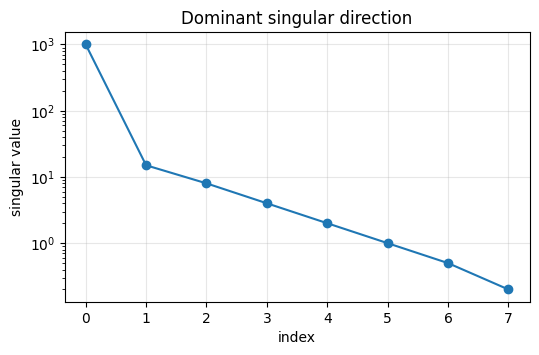

In [5]:
s=np.array([1000.,15.,8.,4.,2.,1.,.5,.2])
A=np.diag(s)
print(f'algebraic rank {np.linalg.matrix_rank(A)} stable rank {stable_rank(A)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(s,marker='o')
plt.xlabel('index')
plt.ylabel('singular value')
plt.title('Dominant singular direction')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** SVD 把矩阵分解成了什么？

**A.** $A=U\Sigma V^T$。$U,V$ orthogonal，$\sigma_i$ 非负递减。$Av_i=\sigma_i u_i$：一组正交输入方向，各自只被缩放再旋转。

**Q2.** $\sigma_i$ 和 $A^TA$ 是什么关系？

**A.** $A^TA=V\Sigma^2V^T$，所以 $\sigma_i^2$ 是 $A^TA$ 的特征值。$\Vert Ax\Vert_2^2=x^TA^TAx$ 就是沿这些方向的能量增益。

**Q3.** $\kappa_2(A)$ 由哪两个量决定？

**A.** 可逆时 $\kappa_2(A)=\sigma_1/\sigma_n$。大 $\sigma_1$ 管 forward amplification，小 $\sigma_n$ 管 inverse sensitivity。

**Q4.** 某层出现 $\sigma_1\gg\sigma_2$ 意味着什么？

**A.** 可能是“单方向高增益”：representation 往一条方向塌，或该方向上的 precision perturbation 被大幅放大。


# Lecture 5 — More on the SVD

### 1. Pseudoinverse

若

$$
A=U\Sigma V^T,
$$

定义

$$
A^+=V\Sigma^+U^T,
\qquad
\Sigma^+_{ii}=\begin{cases}
1/\sigma_i,&\sigma_i>0,\\
0,&\sigma_i=0.
\end{cases}
$$

最关键的数值事实：**小 singular value 会在 inversion 中变成巨大 reciprocal**。

### 2. Best rank-k approximation

截断 SVD：

$$
A_k=U_k\Sigma_kV_k^T.
$$

Eckart–Young 结论。这里 $B$ 是被优化的自由变量，取遍与 $A$ 同形状、秩不超过 $k$ 的所有矩阵，即可行集 $\mathcal{B}_k=\{B\in\mathbb{R}^{m\times n}:\mathrm{rank}(B)\le k\}$：

$$
\Vert A-A_k\Vert_2=\min_{B\in\mathcal{B}_k}\Vert A-B\Vert_2=\sigma_{k+1},
$$

并且

$$
\Vert A-A_k\Vert_F^2=\min_{B\in\mathcal{B}_k}\Vert A-B\Vert_F^2=\sum_{i>k}\sigma_i^2.
$$

换句话说：无论用什么方式构造 rank-$k$ 逼近，误差都不可能小于截断 SVD，$A_k$ 本身就是这个最小化问题的最优解。若 $k\ge\mathrm{rank}(A)$ 则 $\sigma_{k+1}=0$；最优解唯一当且仅当 $\sigma_k>\sigma_{k+1}$（截断处有重奇异值时 $A_k$ 的取法不唯一，但最优误差值唯一）。该结论对任意 unitarily invariant norm 都成立，2-norm 和 Frobenius 只是两个常用特例。

这给出了低秩压缩能做到的最优线性误差边界。

### 3. Distance to rank deficiency

对 full-rank square matrix，最小 singular value 也是到 singular matrix 的 2-norm 距离：

$$
\min_{\Delta A:\,A+\Delta A\ \mathrm{singular}}\Vert \Delta A\Vert_2=\sigma_{\min}(A).
$$

所以 $\sigma_{\min}$ 直接量化“离失去可逆性还有多远”。

### 4. Deployment mapping

一个 $m\times n$ weight 若用 rank-$k$ 因子化：

$$
W\approx U_k\Sigma_kV_k^T,
$$

parameter cost 从 $mn$ 变成约 $k(m+n)$。但 latency 是否下降还取决于 GEMM shape、kernel launch、memory traffic 和 compiler fusion。

### 5. 陷阱：Eckart–Young 最优 $\ne$ 压缩最优

> **延伸，超出原书范围。** Trefethen & Bau 只讲到 Eckart–Young 本身；本节是把它接到实际的 model compression 上，属于自己加的 ML systems 映射。想只跟原书主线的话可以跳过。

Eckart–Young 的最优性是相对于 $\Vert A-B\Vert$ 这个**矩阵范数**说的。但压缩一个 layer 时，真正要控制的是 loss 的增量，一阶近似下是**输出误差**，而输出是否变化取决于权重误差落在哪些方向上——被输入激发得多的方向要紧，输入几乎不去的方向无所谓。

设该层为 $y=Wx$，输入二阶矩 $M=\mathbb{E}[xx^T]$。记**权重误差矩阵**

$$
\Delta_W:=W-\hat W\ \in\mathbb{R}^{m\times n},
$$

注意 $\Delta_W$ 是一个**矩阵**（下标 $W$ 提示它是 $W$ 的误差），所以 $\Delta_Wx$ 表示矩阵乘向量，不是“$x$ 的增量”。则压缩后的期望输出误差为

$$
\begin{aligned}
\mathbb{E}\big\Vert \Delta_Wx\big\Vert_2^2
&=\mathbb{E}\Big[\mathrm{tr}\big(\Delta_W\,xx^T\,\Delta_W^T\big)\Big]
&&\Vert v\Vert_2^2=v^Tv=\mathrm{tr}(vv^T),\ v=\Delta_Wx\\
&=\mathrm{tr}\big(\Delta_W\,\mathbb{E}[xx^T]\,\Delta_W^T\big)
&&\mathbb{E}\text{ 与 trace 均为线性算子，可交换}\\
&=\mathrm{tr}\big(\Delta_W\,SS^T\,\Delta_W^T\big)
&&M=\mathbb{E}[xx^T]=SS^T\\
&=\big\Vert \Delta_WS\big\Vert_F^2
&&\Vert A\Vert_F^2=\mathrm{tr}(AA^T),\ A=\Delta_WS
\end{aligned}
$$

这里 $M$ 对称半正定，故一定可以分解成 $M=SS^T$，$S$ 即 $M$ 的平方根因子（实现上一般取 Cholesky 因子）。

最后一步之所以成立，是因为 $A=\Delta_WS$ 的转置为 $A^T=S^T\Delta_W^T$，于是 $AA^T=\Delta_WSS^T\Delta_W^T$，正是上一行括号里的内容——$\Delta_W^T$ 并没有消失，只是被收进了 $A^T$ 的记号里。

所以要最小化的是 $\Vert (W-\hat W)S\Vert_F$ 而非 $\Vert W-\hat W\Vert_F$。这仍然能用 Eckart–Young 解，只是要先换元。分三步：

**(a) 把 $S$ 吸进去。** $S$ 是右乘，分配律直接成立：

$$
(W-\hat W)S=\underbrace{WS}_{\text{常数}}-\underbrace{\hat WS}_{\text{变量}},
$$

形式上已经是“常数矩阵减一个变量”，正是 Eckart–Young 要的样子。

**(b) 换元 $B=\hat WS$，且这是个双射。** 要把“对 $\hat W$ 优化”换成“对 $B$ 优化”，必须确认两个可行集一一对应，否则换元会改变问题。$S$ 可逆时：

- 正向：$\mathrm{rank}(\hat W)\le k\Rightarrow\mathrm{rank}(B)=\mathrm{rank}(\hat WS)=\mathrm{rank}(\hat W)\le k$（乘可逆矩阵不改变秩）；
- 反向：任给 $B\in\mathcal B_k$，取 $\hat W=BS^{-1}$，同理秩 $\le k$，且确实满足 $\hat WS=B$。

故两个问题等价：

$$
\min_{\mathrm{rank}(\hat W)\le k}\Vert WS-\hat WS\Vert_F=\min_{B\in\mathcal B_k}\Vert WS-B\Vert_F.
$$

$S$ 可逆是不能省的前提——否则反向映射不存在，$S^{-1}$ 也写不出来。

**(c) 套 Eckart–Young，再映射回去。** 右边就是标准的最佳低秩逼近，只不过被逼近的矩阵是 $WS$ 而非 $W$，故 $B^\star=(WS)_k$。用反向映射送回原变量：

$$
\hat W=(WS)_k\,S^{-1}
=\tilde U_k\tilde\Sigma_k\tilde V_k^TS^{-1},
\qquad WS=\tilde U\tilde\Sigma\tilde V^T.
$$

对应的最优目标值是 $\sqrt{\sum_{i>k}\tilde\sigma_i^2}$，其中 $\tilde\sigma_i$ 是 $WS$（不是 $W$）的奇异值。

这就是 activation-aware / whitened SVD（ASVD、SVD-LLM 等方法）的全部数学内容：**在被输入白化后的空间里做截断，再变换回来**。

**部署上 $S^{-1}$ 不产生运行时开销**，因为它可以吸收进右因子：

$$
\hat W=\underbrace{(\tilde U_k\tilde\Sigma_k)}_{m\times k}\underbrace{(\tilde V_k^TS^{-1})}_{k\times n}.
$$

导出时把 $\tilde V_k^TS^{-1}$ 算好存下来即可，参数量仍是 $k(m+n)$，推理时同样是两个 GEMM。$S$ 只活在离线压缩阶段，calibration 完就扔掉。

两个工程前提：

1. $M$ 实际是用少量 calibration data 估的，$\hat M=\frac{1}{N}XX^T$；
2. 上式要求 $S$ **可逆**，即 $M$ 严格正定。样本数不足或某些输入方向恒为零时 $\hat M$ 会奇异，所以实现中一般加 ridge：$\hat M+\lambda I$。这同时也压住了 $S^{-1}$ 那一步的误差放大——该步的条件数是 $\kappa(S)=\sqrt{\kappa(M)}$。

代价是 $\hat W$ 在权重 Frobenius 误差上必然**劣于** plain 截断 SVD——这不矛盾，正是 Eckart–Young 所保证的；我们只是换了一个更贴近任务的度量去最优化。

In [ ]:
m=n=256
Q1,_=np.linalg.qr(rng.normal(size=(m,48)))
Q2,_=np.linalg.qr(rng.normal(size=(n,48)))
sig=np.exp(-np.linspace(0,5,48))

# Main term is already in thin-SVD form (Q1, Q2 have orthonormal columns), so sig are exactly
# its singular values and its rank is 48. The trailing term is elementwise N(0,(1e-3)^2) noise
# that lifts W to full rank 256, modelling weights that are only approximately low rank.
# Caveat: entry scale != operator scale. The noise has sigma_max ~ 1e-3*(sqrt(m)+sqrt(n)) ~ 0.032,
# above the designed tail exp(-5) ~ 0.0067, so the spectrum tracks sig only up to index ~34 and
# then flattens into a noise plateau -- which is why rel_F_error stalls past k=32 below.
# Lower 1e-3 to 1e-5 to expose the full designed spectrum.
W=Q1@np.diag(sig)@Q2.T+1e-3*rng.normal(size=(m,n))
U,s,Vt=np.linalg.svd(W,full_matrices=False)
print(f' k   rel_F_error   ideal_param_compression')
for k in [4,8,16,32,64]:
    Wk=(U[:,:k]*s[:k])@Vt[:k]
    e=relerr(Wk,W)
    comp=(m*n)/(k*(m+n))
    print(f'{k:3d} {e:12.4e} {comp:10.2f}x')

 k   rel_F_error   ideal_param_compression
  4   6.5850e-01      32.00x
  8   4.3748e-01      16.00x
 16   2.0881e-01       8.00x
 32   1.0249e-01       4.00x
 64   7.5949e-02       2.00x


In [38]:
# plain truncated SVD vs activation-aware SVD:
# plain is optimal in weight error (Eckart-Young), activation-aware wins in output error
m=n=256
Q1,_=np.linalg.qr(rng.normal(size=(m,48)))
Q2,_=np.linalg.qr(rng.normal(size=(n,48)))
W=Q1@np.diag(np.exp(-np.linspace(0,5,48)))@Q2.T+1e-5*rng.normal(size=(m,n))

# anisotropic input distribution, deliberately misaligned with W's right singular vectors
Qc,_=np.linalg.qr(rng.normal(size=(n,n)))
sc=np.exp(-np.linspace(0,8,n))
M=(Qc*sc)@Qc.T
S=np.linalg.cholesky(0.5*(M+M.T)+1e-10*np.eye(n))
Sinv=np.linalg.inv(S)
X=(Qc*np.sqrt(sc))@rng.normal(size=(n,4096))

U,s,Vt=np.linalg.svd(W,full_matrices=False)
Ua,sa,Vta=np.linalg.svd(W@S,full_matrices=False)

def w_err(Wh):
    return np.linalg.norm(W-Wh,'fro')/np.linalg.norm(W,'fro')

def out_err(Wh):
    return np.linalg.norm((W-Wh)@X,'fro')/np.linalg.norm(W@X,'fro')

print(f"{'k':>3} {'plain_W':>11} {'aware_W':>11} {'plain_out':>11} {'aware_out':>11}")
for k in [4,8,16,32]:
    Wp=(U[:,:k]*s[:k])@Vt[:k]
    Wa=((Ua[:,:k]*sa[:k])@Vta[:k])@Sinv
    print(f'{k:3d} {w_err(Wp):11.3e} {w_err(Wa):11.3e} {out_err(Wp):11.3e} {out_err(Wa):11.3e}')

  k     plain_W     aware_W   plain_out   aware_out
  4   6.534e-01   6.864e-01   6.689e-01   6.437e-01
  8   4.269e-01   4.630e-01   4.449e-01   4.119e-01
 16   1.822e-01   2.011e-01   1.874e-01   1.653e-01
 32   3.268e-02   3.987e-02   3.204e-02   2.562e-02


**ML numerics 自测**

**Q1.** 伪逆里最危险的代数步骤是什么？

**A.** $\Sigma^+_{ii}=1/\sigma_i$（$\sigma_i>0$）。小 singular value 一取倒数就变成巨大增益。

**Q2.** 截断 SVD 的最优误差是多少？

**A.** Eckart–Young：$\min_{\mathrm{rank}(B)\le k}\Vert A-B\Vert_2=\sigma_{k+1}$，Frobenius 误差平方是 $\sum_{i>k}\sigma_i^2$。

**Q3.** $\sigma_{\min}$ 除了 inversion，还量化什么？

**A.** 到奇异矩阵的 2-norm 距离：$\min\Vert\Delta A\Vert_2=\sigma_{\min}(A)$。它告诉你离失去可逆性还有多远。

**Q4.** rank-$k$ 压缩省参数，就一定更快吗？

**A.** 参数从 $mn$ 变成约 $k(m+n)$。latency 还取决于 GEMM shape、kernel launch、memory traffic 和 fusion。
